In [9]:
!pip install loguru

In [10]:
"""
Baby U-Net: Data Pipeline + Architecture — Person 1 Implementation
=================================================================
Montgomery County Chest X-Ray dataset + a compact U-Net capped at 128 channels.

Sections
--------
1. Imports & configuration
2. Dataset download helper
3. MontgomeryDataset  (DataLoader-ready)
4. Augmentation pipeline
5. Baby U-Net architecture
6. Hook registration (exposes every intermediate activation)
7. Training / validation loop
8. Metric helpers  (IoU & Dice)
9. Main entry-point
"""

# ── 1. Imports & configuration ────────────────────────────────────────────────
import os
import zipfile
import urllib.request
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

from loguru import logger

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
matplotlib.use("Agg")          # non-interactive backend — safe in all environments
%matplotlib inline

# Central config — change these to suit your machine
CFG = {
    # Data
    "data_dir":   "data/montgomery/MontgomerySet",   # where the dataset will be stored
    "img_size":    256,                  # resize to this square size
    "in_channels": 1,                    # grayscale X-rays
    # Model
    "base_ch":     16,                   # channel width at the first encoder stage
    "max_ch":      128,                  # hard cap on channels (spec requirement)
    # Training
    "batch_size":  8,
    "num_epochs":  30,
    "lr":          1e-3,
    "seed":        42,
    # Split fractions  (must sum to 1)
    "train_frac":  0.70,
    "val_frac":    0.15,
    "test_frac":   0.15,
    # Device
    "device":      "cuda" if torch.cuda.is_available() else "cpu",
    # Checkpointing
    "ckpt_path":   "baby_unet_best.pth",
}

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])


# ── 2. Dataset download helper ────────────────────────────────────────────────
# The Montgomery dataset is hosted by the US National Library of Medicine.
# This function downloads and unzips it if it hasn't already been fetched.

MONTGOMERY_URL = (
    "https://openi.nlm.nih.gov/imgs/collections/NLM-MontgomeryCXRSet.zip"
)

def download_montgomery(data_dir: str = CFG["data_dir"]) -> Path:
    """
    Download the Montgomery County CXR dataset from the NLM OpenI server.

    The archive contains:
      CXR_png/          — 138 greyscale chest X-rays in PNG format
      ManualMask/left/  — left-lung binary masks
      ManualMask/right/ — right-lung binary masks

    Returns the root directory of the extracted dataset.
    """
    root = Path(data_dir)
    img_dir = root / "CXR_png"

    if img_dir.exists() and any(img_dir.iterdir()):
        logger.info(f"[data] Dataset already present at {root}")
        return root

    root.mkdir(parents=True, exist_ok=True)
    zip_path = root / "montgomery.zip"

    if not zip_path.exists():
        logger.info(f"[data] Downloading Montgomery dataset …")
        urllib.request.urlretrieve(MONTGOMERY_URL, zip_path)
        logger.info(f"[data] Download complete → {zip_path}")

    logger.info("[data] Extracting archive …")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(root)
    logger.info(f"[data] Extracted to {root}")

    return root


# ── 3. MontgomeryDataset ──────────────────────────────────────────────────────
# Each sample = one X-ray + its combined lung mask (left ∪ right).
# The mask is a binary image where 1 = lung pixels, 0 = background.

class MontgomeryDataset(Dataset):
    """
    PyTorch Dataset for the Montgomery County Chest X-Ray collection.

    Parameters
    ----------
    root : str or Path
        Root directory of the extracted dataset.
    img_size : int
        Both spatial dimensions are resized to this value.
    transform : callable, optional
        Augmentation / transform applied to the *image* tensor.
    mask_transform : callable, optional
        Same spatial transform applied to the *mask* tensor.
        Must produce a binary tensor with values in {0, 1}.
    """

    def __init__(
        self,
        root: str,
        img_size: int = CFG["img_size"],
        transform=None,
        mask_transform=None,
    ):
        self.root        = Path(root)
        self.img_size    = img_size
        self.transform   = transform
        self.mask_transform = mask_transform

        # Collect all image paths and derive corresponding mask paths
        img_dir   = self.root / "CXR_png"
        left_dir  = self.root / "ManualMask" / "leftMask"
        right_dir = self.root / "ManualMask" / "rightMask"

        self.samples: List[Tuple[Path, Path, Path]] = []
        for img_path in sorted(img_dir.glob("*.png")):
            stem        = img_path.stem          # e.g. "MCUCXR_0001_0"
            left_mask   = left_dir  / img_path.name
            right_mask  = right_dir / img_path.name
            if left_mask.exists() and right_mask.exists():
                self.samples.append((img_path, left_mask, right_mask))

        if len(self.samples) == 0:
            raise FileNotFoundError(
                f"No images found under {img_dir}. "
                "Run download_montgomery() first."
            )

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path, left_path, right_path = self.samples[idx]

        # ── Load & resize image ────────────────────────────────────────────
        # Convert to grayscale ('L') so we get a single channel input.
        image = Image.open(img_path).convert("L").resize(
            (self.img_size, self.img_size), Image.BILINEAR
        )

        # ── Load & combine left + right lung masks ─────────────────────────
        # Each mask file is a grayscale PNG where white (255) = lung region.
        # We merge them with a logical OR to get the full lung segmentation.
        left  = np.array(Image.open(left_path ).convert("L").resize(
            (self.img_size, self.img_size), Image.NEAREST
        ))
        right = np.array(Image.open(right_path).convert("L").resize(
            (self.img_size, self.img_size), Image.NEAREST
        ))
        mask_np = ((left > 127) | (right > 127)).astype(np.uint8)  # binary {0,1}
        mask    = Image.fromarray(mask_np * 255)                    # PIL for transforms

        # ── Apply transforms ───────────────────────────────────────────────
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)   # → [1, H, W], float32 in [0,1]

        if self.mask_transform:
            mask = self.mask_transform(mask)
        else:
            mask = transforms.ToTensor()(mask)     # → [1, H, W], float32 in {0,1}

        # Binarise mask (ToTensor scales 255 → 1.0, threshold at 0.5 to be safe)
        mask = (mask > 0.5).float()

        return image, mask


# ── 4. Augmentation pipeline ──────────────────────────────────────────────────
# Training augmentations must be applied identically to image AND mask.
# The pattern here is deterministic: we build a pair of transform pipelines
# that share the same random state by seeding inside the Dataset.__getitem__
# call.  A simpler (and commonly-used) approach for segmentation is to apply
# only *geometric* augmentations to both and *photometric* ones only to the
# image.  We follow that convention here.

def make_transforms(img_size: int = CFG["img_size"]):
    """
    Returns (train_img_tf, train_mask_tf, val_img_tf, val_mask_tf).

    Geometric augmentations (horizontal flip, small rotation) are captured
    in a shared torchvision.transforms pipeline.  Because the Montgomery
    images are chest X-rays we keep augmentations mild — no vertical flips
    (lungs must stay at the top) and small rotation angles only.

    NOTE: For production use, consider albumentations or torchvision v2
    which can apply joint image-mask transforms deterministically.
    """
    # Normalisation statistics derived from greyscale ImageNet proxy
    # (chest X-ray datasets don't always publish their own stats).
    mean, std = [0.5], [0.5]      # maps [0,1] → [-1,1]; safe default

    train_img_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=8),
        transforms.ColorJitter(brightness=0.15, contrast=0.15),
        transforms.ToTensor(),                    # [0,255] → [0,1]
        transforms.Normalize(mean, std),
    ])

    train_mask_tf = transforms.Compose([
        # Must mirror the geometric ops in train_img_tf (same random seed!)
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=8),
        # No colour jitter for masks
        transforms.ToTensor(),                    # values become {0.0, 1.0}
    ])

    val_img_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_mask_tf = transforms.Compose([
        transforms.ToTensor(),
    ])

    return train_img_tf, train_mask_tf, val_img_tf, val_mask_tf


def build_dataloaders(
    root: str,
    batch_size: int = CFG["batch_size"],
    img_size:   int = CFG["img_size"],
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Split the dataset into train / val / test and return three DataLoaders.

    The split is performed *after* building the full dataset so that all
    three splits come from the same shuffled pool — preventing data leakage
    that could arise from alphabetical ordering of patient IDs.
    """
    train_img_tf, train_mask_tf, val_img_tf, val_mask_tf = make_transforms(img_size)

    # Full dataset with training augmentations (we'll override val/test below)
    full_dataset = MontgomeryDataset(
        root       = root,
        img_size   = img_size,
        transform  = train_img_tf,
        mask_transform = train_mask_tf,
    )

    n       = len(full_dataset)
    n_train = int(n * CFG["train_frac"])
    n_val   = int(n * CFG["val_frac"])
    n_test  = n - n_train - n_val      # absorbs any rounding remainder

    generator = torch.Generator().manual_seed(CFG["seed"])
    train_ds, val_ds, test_ds = random_split(
        full_dataset, [n_train, n_val, n_test], generator=generator
    )

    # Override transforms on val/test splits (no augmentation)
    # We access the underlying dataset and patch the subset's __getitem__
    # by wrapping it in a thin adapter.
    class _TransformOverride(Dataset):
        def __init__(self, subset, img_tf, mask_tf):
            self.subset  = subset
            self.img_tf  = img_tf
            self.mask_tf = mask_tf

        def __len__(self):
            return len(self.subset)

        def __getitem__(self, idx):
            img_path, left_path, right_path = \
                self.subset.dataset.samples[self.subset.indices[idx]]
            ds = self.subset.dataset
            # Reload with override transforms
            image = Image.open(img_path).convert("L").resize(
                (ds.img_size, ds.img_size), Image.BILINEAR
            )
            left  = np.array(Image.open(left_path).convert("L").resize(
                (ds.img_size, ds.img_size), Image.NEAREST))
            right = np.array(Image.open(right_path).convert("L").resize(
                (ds.img_size, ds.img_size), Image.NEAREST))
            mask_np = ((left > 127) | (right > 127)).astype(np.uint8)
            mask = Image.fromarray(mask_np * 255)

            image = self.img_tf(image)
            mask  = self.mask_tf(mask)
            mask  = (mask > 0.5).float()
            return image, mask

    _, _, val_img_tf, val_mask_tf = make_transforms(img_size)
    val_ds  = _TransformOverride(val_ds,  val_img_tf, val_mask_tf)
    test_ds = _TransformOverride(test_ds, val_img_tf, val_mask_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    logger.info(f"[data] Split → train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")
    return train_loader, val_loader, test_loader


# ── 5. Baby U-Net architecture ────────────────────────────────────────────────
#
# Encoder path (downsampling):
#   Stage 0: 1   → base_ch          (no pooling — first conv block)
#   Stage 1: bc  → bc*2             (MaxPool → conv block)
#   Stage 2: bc2 → bc*4             (MaxPool → conv block)
#   Stage 3: bc4 → min(bc*8, 128)   (MaxPool → conv block)
#
# Bottleneck:
#   Stage 4: bc8 → 128              (MaxPool → conv block, capped at 128)
#
# Decoder path (upsampling with skip connections):
#   Up 3: concat(up(bottleneck), enc3) → bc*8
#   Up 2: concat(up(dec3),       enc2) → bc*4
#   Up 1: concat(up(dec2),       enc1) → bc*2
#   Up 0: concat(up(dec1),       enc0) → bc
#
# Output: 1×1 conv → 1 channel → sigmoid → binary mask

def _ch(n: int) -> int:
    """Clamp channel count to the spec's maximum of 128."""
    return min(n, CFG["max_ch"])


class ConvBlock(nn.Module):
    """
    Two consecutive Conv2d → BatchNorm → ReLU operations.
    This is the basic building block used in every encoder and decoder stage.
    Padding=1 keeps the spatial size constant within the block.
    """

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UpBlock(nn.Module):
    """
    Decoder stage: bilinear upsample → concatenate skip → ConvBlock.

    Using bilinear upsampling followed by a conv (rather than a transposed
    conv) avoids the checkerboard artefacts that transposed convolutions can
    introduce in segmentation outputs.
    """

    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        """
        Parameters
        ----------
        in_ch   : channels coming from the *lower* (deeper) decoder stage
        skip_ch : channels coming from the encoder skip connection
        out_ch  : output channels of this block
        """
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        # If spatial sizes differ by 1 pixel (odd input size), pad x to match skip.
        if x.shape != skip.shape:
            x = F.pad(x, [0, skip.shape[-1] - x.shape[-1],
                          0, skip.shape[-2] - x.shape[-2]])
        x = torch.cat([x, skip], dim=1)   # channel-wise concatenation
        return self.conv(x)


class BabyUNet(nn.Module):
    """
    Compact U-Net for binary lung segmentation.

    Architecture spec:
    - 4 encoder stages + bottleneck + 4 decoder stages
    - Channel progression doubles each stage, hard-capped at 128
    - Skip connections from every encoder stage to its mirrored decoder stage
    - Final 1×1 conv + sigmoid produces a single-channel probability map
    - Named PyTorch hooks expose all intermediate activations (see register_hooks)

    Parameters
    ----------
    in_channels : int
        Number of input image channels (1 for greyscale).
    base_ch : int
        Number of channels at the first encoder stage.  Subsequent stages
        double this, capped at `max_ch`.
    """

    def __init__(
        self,
        in_channels: int = CFG["in_channels"],
        base_ch:     int = CFG["base_ch"],
    ):
        super().__init__()
        bc = base_ch

        # ── Encoder ──────────────────────────────────────────────────────────
        # Each stage: MaxPool2d (except stage 0) → ConvBlock
        # Tensor shapes (for img_size=256, bc=16):
        #   enc0: [B,  16, 256, 256]
        #   enc1: [B,  32, 128, 128]
        #   enc2: [B,  64,  64,  64]
        #   enc3: [B, 128,  32,  32]   ← already capped
        self.enc0 = ConvBlock(in_channels, _ch(bc))
        self.enc1 = ConvBlock(_ch(bc),     _ch(bc * 2))
        self.enc2 = ConvBlock(_ch(bc * 2), _ch(bc * 4))
        self.enc3 = ConvBlock(_ch(bc * 4), _ch(bc * 8))

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Bottleneck ────────────────────────────────────────────────────────
        # Deepest, most compressed representation.
        # Shape: [B, 128, 16, 16]
        self.bottleneck = ConvBlock(_ch(bc * 8), _ch(bc * 16))

        # ── Decoder ───────────────────────────────────────────────────────────
        # Each UpBlock upsamples, concatenates the matching encoder skip, then
        # applies a ConvBlock.  Channel counts mirror the encoder in reverse.
        self.up3 = UpBlock(_ch(bc * 16), _ch(bc * 8), _ch(bc * 8))
        self.up2 = UpBlock(_ch(bc * 8),  _ch(bc * 4), _ch(bc * 4))
        self.up1 = UpBlock(_ch(bc * 4),  _ch(bc * 2), _ch(bc * 2))
        self.up0 = UpBlock(_ch(bc * 2),  _ch(bc),     _ch(bc))

        # ── Output head ───────────────────────────────────────────────────────
        # 1×1 conv reduces to a single channel; sigmoid maps to (0,1).
        self.out_conv = nn.Conv2d(_ch(bc), 1, kernel_size=1)

        # ── Hook storage ──────────────────────────────────────────────────────
        # Populated by register_hooks(); see Section 6.
        self._activations: Dict[str, torch.Tensor] = {}
        self._hooks: List[torch.utils.hooks.RemovableHook] = []

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ── Encoder pass ─────────────────────────────────────────────────────
        e0 = self.enc0(x)              # full resolution
        e1 = self.enc1(self.pool(e0))  # ½ resolution
        e2 = self.enc2(self.pool(e1))  # ¼ resolution
        e3 = self.enc3(self.pool(e2))  # ⅛ resolution

        # ── Bottleneck ────────────────────────────────────────────────────────
        bn = self.bottleneck(self.pool(e3))   # 1/16 resolution

        # ── Decoder pass (skip connections e3→e0 injected here) ──────────────
        d3 = self.up3(bn, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)
        d0 = self.up0(d1, e0)

        # ── Output ────────────────────────────────────────────────────────────
        logits = self.out_conv(d0)             # [B, 1, H, W]
        return torch.sigmoid(logits)           # probability map in (0,1)


# ── 6. Hook registration ──────────────────────────────────────────────────────
# PyTorch forward hooks let us capture intermediate activations without
# modifying the forward() method.  P2 and P3 will call get_activations()
# after each forward pass to extract the tensors they need.

def register_hooks(model: BabyUNet) -> None:
    """
    Attach named forward hooks to every encoder stage, the bottleneck,
    and every decoder stage.

    After a forward pass, call model.get_activations() to retrieve a dict
    mapping layer_name → activation tensor (detached, on CPU).

    Layer name reference (printed by print_architecture_reference):
      enc0, enc1, enc2, enc3  — encoder ConvBlocks
      bottleneck               — deepest representation
      up3, up2, up1, up0       — decoder UpBlocks
    """
    def _make_hook(name: str):
        def hook(module, input, output):
            # Store a detached CPU copy so GPU memory isn't held.
            model._activations[name] = output.detach().cpu()
        return hook

    named_blocks = [
        ("enc0",       model.enc0),
        ("enc1",       model.enc1),
        ("enc2",       model.enc2),
        ("enc3",       model.enc3),
        ("bottleneck", model.bottleneck),
        ("up3",        model.up3.conv),
        ("up2",        model.up2.conv),
        ("up1",        model.up1.conv),
        ("up0",        model.up0.conv),
    ]

    for name, block in named_blocks:
        h = block.register_forward_hook(_make_hook(name))
        model._hooks.append(h)


def remove_hooks(model: BabyUNet) -> None:
    """Remove all registered hooks (call after analysis to free memory)."""
    for h in model._hooks:
        h.remove()
    model._hooks.clear()


def get_activations(model: BabyUNet) -> Dict[str, torch.Tensor]:
    """Return a snapshot of the latest intermediate activations."""
    return dict(model._activations)


def print_architecture_reference(model: BabyUNet, img_size: int = CFG["img_size"], device: str = CFG["device"]) -> None:
    """
    Run a single dummy forward pass and print layer names with tensor shapes.
    Intended as the 'architecture reference doc' for P2 and P3.
    """
    register_hooks(model)
    dummy = torch.zeros(1, CFG["in_channels"], img_size, img_size)
    dummy = dummy.to(device)
    with torch.no_grad():
        _ = model(dummy)
    acts = get_activations(model)
    remove_hooks(model)

    logger.info("\n" + "="*60)
    logger.info(" Architecture Reference — Baby U-Net")
    logger.info("="*60)
    logger.info(f"{'Layer':<15} {'Shape (B, C, H, W)':<30} {'#Params'}")
    logger.info("-"*60)
    for name, tensor in acts.items():
        b, c, h, w = tensor.shape
        logger.info(f"{name:<15} [{b}, {c:>3}, {h:>3}, {w:>3}]")
    total_params = sum(p.numel() for p in model.parameters())
    logger.info("-"*60)
    logger.info(f"Total trainable parameters: {total_params:,}")
    logger.info("="*60 + "\n")


# ── 7. Training / validation loop ────────────────────────────────────────────

class DiceBCELoss(nn.Module):
    """
    Combined Binary Cross-Entropy + Dice loss.

    BCE handles per-pixel classification; Dice directly optimises the
    overlap metric we report, and is robust to class imbalance (lungs ≈ 30%
    of pixels in chest X-rays).
    """

    def __init__(self, bce_weight: float = 0.5):
        super().__init__()
        self.bce_weight  = bce_weight
        self.dice_weight = 1.0 - bce_weight
        self.bce = nn.BCELoss()

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        bce_loss  = self.bce(pred, target)
        dice_loss = self._dice_loss(pred, target)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

    @staticmethod
    def _dice_loss(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
        pred_flat   = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        return 1.0 - (2.0 * intersection + eps) / (pred_flat.sum() + target_flat.sum() + eps)


def train_one_epoch(
    model:      BabyUNet,
    loader:     DataLoader,
    optimizer:  torch.optim.Optimizer,
    criterion:  nn.Module,
    device:     str,
) -> float:
    """Run one full training epoch; returns mean loss."""
    model.train()
    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        optimizer.zero_grad()
        preds = model(images)
        loss  = criterion(preds, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def validate(
    model:     BabyUNet,
    loader:    DataLoader,
    criterion: nn.Module,
    device:    str,
) -> Tuple[float, float, float]:
    """Evaluate on val/test split; returns (loss, mean_iou, mean_dice)."""
    model.eval()
    total_loss = 0.0
    iou_scores, dice_scores = [], []

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        preds = model(images)
        loss  = criterion(preds, masks)
        total_loss += loss.item() * images.size(0)

        pred_bin = (preds > 0.5).float()
        iou_scores.append( iou(pred_bin, masks).item() )
        dice_scores.append( dice(pred_bin, masks).item() )

    mean_loss = total_loss / len(loader.dataset)
    return mean_loss, float(np.mean(iou_scores)), float(np.mean(dice_scores))


# ── 8. Metric helpers ─────────────────────────────────────────────────────────

def iou(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """
    Intersection-over-Union (Jaccard index) for a batch.
    pred and target must be binary tensors of shape [B, 1, H, W].
    """
    pred_f   = pred.view(pred.size(0), -1).float()
    target_f = target.view(target.size(0), -1).float()
    inter    = (pred_f * target_f).sum(dim=1)
    union    = pred_f.sum(dim=1) + target_f.sum(dim=1) - inter
    return ((inter + eps) / (union + eps)).mean()


def dice(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """
    Sørensen–Dice coefficient for a batch.
    pred and target must be binary tensors of shape [B, 1, H, W].
    """
    pred_f   = pred.view(pred.size(0), -1).float()
    target_f = target.view(target.size(0), -1).float()
    inter    = (pred_f * target_f).sum(dim=1)
    return ((2.0 * inter + eps) / (pred_f.sum(dim=1) + target_f.sum(dim=1) + eps)).mean()

# ── 9. Training-curve plots ──────────────────────────────────────────────────

def plot_training_curves(
    history:        Dict[str, List[float]],
    freeze_epochs:  int = 0,
    save_path:      str = "training_curves.png",
) -> None:
    """
    Save a two-panel figure showing loss and segmentation metrics across all
    training epochs.

    Parameters
    ----------
    history : dict with keys
        "train_loss", "val_loss", "val_iou", "val_dice"
        Each value is a list of length num_epochs, one entry per epoch.
    freeze_epochs : int
        Epoch index at which Phase 2 (encoder unfreeze) begins.
        A vertical dashed line is drawn here so the reader can see the
        effect of unfreezing on both loss and metrics.
    save_path : str
        File path for the saved PNG (default: "training_curves.png").

    Layout
    ------
    Left panel  — Loss curves (train + val)
    Right panel — Segmentation metrics (val IoU + val Dice)

    Both panels share the same x-axis (epoch number) and display the
    phase boundary, the best-val-IoU epoch marker, and a shaded region
    indicating Phase 1 (frozen encoder).
    """
    epochs     = list(range(1, len(history["train_loss"]) + 1))
    best_epoch = int(np.argmax(history["val_iou"])) + 1   # 1-indexed

    # ── Style ─────────────────────────────────────────────────────────────────
    # Use a clean, publication-friendly style if available, otherwise fall back.
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        plt.style.use("ggplot")

    PHASE1_COLOR  = "#E8F0FE"   # light blue tint for frozen-encoder region
    TRAIN_COLOR   = "#2563EB"   # blue  — training loss
    VAL_COLOR     = "#DC2626"   # red   — validation loss / metrics
    IOU_COLOR     = "#16A34A"   # green — IoU
    DICE_COLOR    = "#9333EA"   # purple — Dice
    PHASE_LINE    = "#64748B"   # slate — phase boundary line
    BEST_COLOR    = "#F59E0B"   # amber — best epoch marker

    fig, (ax_loss, ax_metrics) = plt.subplots(
        1, 2, figsize=(13, 5), constrained_layout=True
    )
    fig.suptitle(
        "Baby-UNet — Training Curves",
        fontsize=14, fontweight="bold", y=1.02
    )

    def _add_phase_annotation(ax, y_top):
        """
        Shade Phase 1 (frozen encoder) and draw the unfreeze boundary line.
        Also annotate the best-IoU epoch with a vertical marker.
        """
        # Shaded frozen-encoder region (Phase 1)
        ax.axvspan(0.5, freeze_epochs + 0.5,
                   color=PHASE1_COLOR, alpha=0.6, zorder=0, label="Phase 1 (frozen encoder)")

        # Phase boundary dashed line
        ax.axvline(freeze_epochs + 0.5, color=PHASE_LINE,
                   linestyle="--", linewidth=1.2, zorder=2)
        ax.text(freeze_epochs + 0.7, y_top * 0.97,
                "encoder\nunfrozen", fontsize=7.5, color=PHASE_LINE,
                va="top", linespacing=1.4)

        # Best epoch marker
        ax.axvline(best_epoch, color=BEST_COLOR,
                   linestyle=":", linewidth=1.5, zorder=2)
        ax.text(best_epoch + 0.2, y_top * 0.97,
                f"best\n(ep {best_epoch})", fontsize=7.5, color=BEST_COLOR,
                va="top", linespacing=1.4)

    # ── Left panel: Loss ──────────────────────────────────────────────────────
    ax_loss.plot(epochs, history["train_loss"],
                 color=TRAIN_COLOR, linewidth=2, marker="o", markersize=3,
                 label="Train loss", zorder=3)
    ax_loss.plot(epochs, history["val_loss"],
                 color=VAL_COLOR, linewidth=2, marker="s", markersize=3,
                 linestyle="--", label="Val loss", zorder=3)

    y_top_loss = max(max(history["train_loss"]), max(history["val_loss"])) * 1.05
    if freeze_epochs != 0:
      _add_phase_annotation(ax_loss, y_top_loss)

    ax_loss.set_xlim(0.5, len(epochs) + 0.5)
    ax_loss.set_ylim(bottom=0)
    ax_loss.set_xlabel("Epoch", fontsize=11)
    ax_loss.set_ylabel("DiceBCE Loss", fontsize=11)
    ax_loss.set_title("Loss", fontsize=12)
    # Custom legend: merge phase shading entry with line entries
    phase_patch = mpatches.Patch(color=PHASE1_COLOR, alpha=0.6, label="Phase 1 (frozen)")
    ax_loss.legend(handles=[
        phase_patch,
        plt.Line2D([], [], color=TRAIN_COLOR, linewidth=2, marker="o", markersize=4, label="Train loss"),
        plt.Line2D([], [], color=VAL_COLOR,   linewidth=2, marker="s", markersize=4, linestyle="--", label="Val loss"),
    ], fontsize=9, loc="upper right")

    # ── Right panel: Metrics ──────────────────────────────────────────────────
    ax_metrics.plot(epochs, history["val_iou"],
                    color=IOU_COLOR, linewidth=2, marker="o", markersize=3,
                    label="Val IoU", zorder=3)
    ax_metrics.plot(epochs, history["val_dice"],
                    color=DICE_COLOR, linewidth=2, marker="s", markersize=3,
                    linestyle="--", label="Val Dice", zorder=3)

    # Highlight the best IoU value with a filled dot
    best_iou_val = history["val_iou"][best_epoch - 1]
    ax_metrics.scatter([best_epoch], [best_iou_val],
                       color=BEST_COLOR, s=80, zorder=5, label=f"Best IoU ({best_iou_val:.3f})")

    y_top_metrics = 1.0
    if freeze_epochs != 0:
      _add_phase_annotation(ax_metrics, y_top_metrics)

    ax_metrics.set_xlim(0.5, len(epochs) + 0.5)
    ax_metrics.set_ylim(0, 1.05)
    ax_metrics.set_xlabel("Epoch", fontsize=11)
    ax_metrics.set_ylabel("Score", fontsize=11)
    ax_metrics.set_title("Validation Metrics", fontsize=12)
    phase_patch2 = mpatches.Patch(color=PHASE1_COLOR, alpha=0.6, label="Phase 1 (frozen)")
    ax_metrics.legend(handles=[
        phase_patch2,
        plt.Line2D([], [], color=IOU_COLOR,   linewidth=2, marker="o", markersize=4, label="Val IoU"),
        plt.Line2D([], [], color=DICE_COLOR,  linewidth=2, marker="s", markersize=4, linestyle="--", label="Val Dice"),
        plt.Line2D([], [], color=BEST_COLOR,  linewidth=0, marker="o", markersize=7, label=f"Best IoU ({best_iou_val:.3f})"),
    ], fontsize=9, loc="lower right")

    # ── Save ──────────────────────────────────────────────────────────────────
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    logger.info(f"[plot] Training curves saved → {save_path}")


# ── 10. Main entry-point ───────────────────────────────────────────────────────

def main():
    device = CFG["device"]
    logger.info(f"[main] Using device: {device}")

    # ── Step 1: Download data ─────────────────────────────────────────────────
    root = download_montgomery(CFG["data_dir"])

    # ── Step 2: Build DataLoaders ─────────────────────────────────────────────
    train_loader, val_loader, test_loader = build_dataloaders(
        root       = root,
        batch_size = CFG["batch_size"],
        img_size   = CFG["img_size"],
    )

    # ── Step 3: Instantiate model ─────────────────────────────────────────────
    model = BabyUNet(
        in_channels = CFG["in_channels"],
        base_ch     = CFG["base_ch"],
    ).to(device)

    # Print architecture reference doc for P2 and P3
    print_architecture_reference(model, img_size=CFG["img_size"])

    # Register hooks so activations are captured during the training run
    # (useful for P1's own skip-connection analysis)
    register_hooks(model)

    # ── Step 4: Training ──────────────────────────────────────────────────────
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )
    criterion = DiceBCELoss(bce_weight=0.5)

    best_val_iou  = 0.0
    best_ckpt     = CFG["ckpt_path"]

    # History accumulator — one entry appended per epoch across both phases.
    # Collected here (not inside helpers) so the full run is in one place.
    history: Dict[str, List[float]] = {
        "train_loss": [],
        "val_loss":   [],
        "val_iou":    [],
        "val_dice":   [],
    }

    for epoch in range(1, CFG["num_epochs"] + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_iou, val_dice = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)
        history["val_dice"].append(val_dice)

        logger.info(
            f"Epoch [{epoch:>3}/{CFG['num_epochs']}] "
            f"train_loss: {train_loss:.4f}  "
            f"val_loss: {val_loss:.4f}  "
            f"val_IoU: {val_iou:.4f}  "
            f"val_Dice: {val_dice:.4f}"
        )

        # Save checkpoint whenever validation IoU improves
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(
                {
                    "epoch":      epoch,
                    "state_dict": model.state_dict(),
                    "val_iou":    val_iou,
                    "val_dice":   val_dice,
                    "cfg":        CFG,
                },
                best_ckpt,
            )
            logger.info(f"  ✓ New best checkpoint saved → {best_ckpt}  (IoU={val_iou:.4f})")

    # ── Step 5: Plot training curves ──────────────────────────────────────────
    plot_training_curves(
        history        = history,
        save_path      = "training_curves.png",
    )

    # ── Step 6: Final test evaluation (Phase 1 metrics) ───────────────────────
    logger.info("\n[eval] Loading best checkpoint for test evaluation …")
    checkpoint = torch.load(best_ckpt, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])

    _, test_iou, test_dice = validate(model, test_loader, criterion, device)
    logger.info(f"\n{'='*40}")
    logger.info(f" Phase 1 Test Metrics")
    logger.info(f"{'='*40}")
    logger.info(f"  IoU  (Jaccard): {test_iou:.4f}")
    logger.info(f"  Dice (F1):      {test_dice:.4f}")
    logger.info(f"{'='*40}\n")

    logger.info(f"[main] Shared checkpoint ready at: {best_ckpt}")
    logger.info("[main] P2 and P3 can load it with:")
    logger.info("       torch.load('baby_unet_best.pth')['state_dict']")


if __name__ == "__main__":
    main()

2026-04-14 04:11:48.073 | INFO     | __main__:main:832 - [main] Using device: cuda
2026-04-14 04:11:48.074 | INFO     | __main__:download_montgomery:93 - [data] Dataset already present at data/montgomery/MontgomerySet
2026-04-14 04:11:48.083 | INFO     | __main__:build_dataloaders:332 - [data] Split → train: 96, val: 20, test: 22
2026-04-14 04:11:48.164 | INFO     | __main__:print_architecture_reference:564 - 
2026-04-14 04:11:48.166 | INFO     | __main__:print_architecture_reference:565 -  Architecture Reference — Baby U-Net
2026-04-14 04:11:48.166 | INFO     | __main__:print_architecture_reference:566 - ============================================================
2026-04-14 04:11:48.167 | INFO     | __main__:print_architecture_reference:567 - Layer           Shape (B, C, H, W)             #Params
2026-04-14 04:11:48.170 | INFO     | __main__:print_architecture_reference:568 - ------------------------------------------------------------
2026-04-14 04:11:48.171 | INFO     | __main__:pr

In [11]:
def plot_saved_img(img_path: str = ""):
  if img_path == "":
    logger.error("No path provided!")
    return

  img = np.asarray(Image.open(img_path))
  plt.figure(figsize=(20,20))
  plt.imshow(img)
  plt.show()

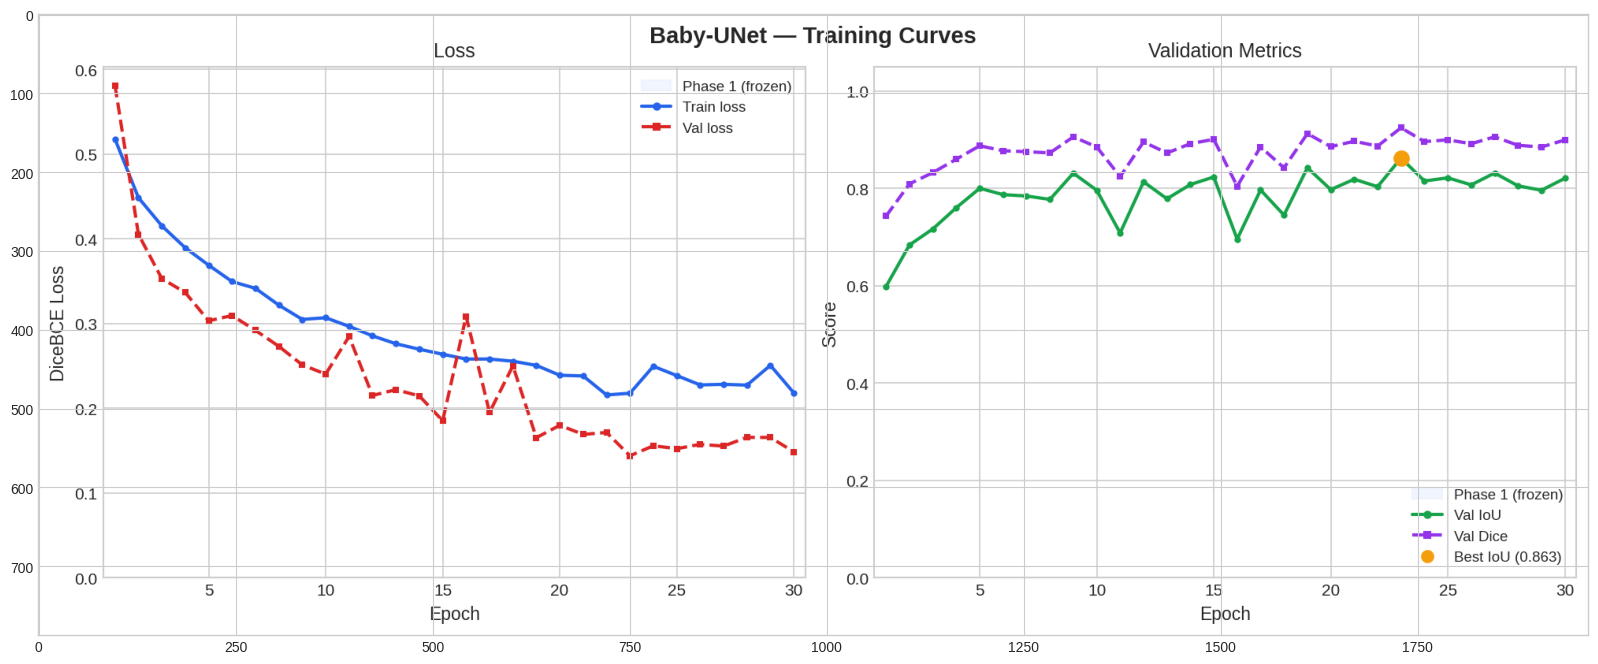

In [22]:
training_curves_path = "/content/training_curves.png"
plot_saved_img(img_path=training_curves_path)

In [19]:
def plot_predictions(
    model:     BabyUNet,
    loader:    DataLoader,
    device:    str,
    n:         int = 5,
    save_path: str = "predictions.png",
) -> None:
    """
    Plot n samples in a (n rows × 3 cols) grid:
      col 0 — Ground Truth Mask
      col 1 — Original Image
      col 2 — Predicted Mask   (threshold = 0.5)

    Parameters
    ----------
    model     : Trained BabyUNet instance.
    loader    : Any DataLoader whose dataset returns (image, mask) pairs
                with ImageNet-normalised images.
    device    : "cuda" or "cpu".
    n         : Number of samples to display (default 5).
    save_path : Output PNG file path.
    """

    # ── Collect n samples ─────────────────────────────────────────────────────
    model.eval()
    images_out, gt_masks, pred_masks = [], [], []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            preds  = model(images)             # [B, 1, H, W], values in (0,1)

            for i in range(images.size(0)):
                if len(images_out) >= n:
                    break
                images_out.append(images[i])
                gt_masks.append(masks[i, 0].numpy())           # [H, W]
                pred_masks.append((preds[i, 0].cpu().numpy() > 0.5).astype(np.uint8))

            if len(images_out) >= n:
                break

    actual_n = len(images_out)   # may be < n if loader has fewer samples

    # ── Build figure ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        actual_n, 3,
        figsize=(9, actual_n * 3),
        constrained_layout=True,
    )

    # Normalise axes to 2-D array even when actual_n == 1
    if actual_n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["Ground Truth Mask", "Original Image", "Predicted Mask"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight="bold", pad=6)

    for row in range(actual_n):
        # Col 0 — ground truth mask (greyscale binary)
        axes[row, 0].imshow(gt_masks[row],   cmap="gray", vmin=0, vmax=1)
        # Col 1 — original X-ray (RGB after denorm; appears greyscale, which is correct)
        axes[row, 1].imshow(images_out[row].squeeze().cpu())
        # Col 2 — predicted mask (greyscale binary)
        axes[row, 2].imshow(pred_masks[row], cmap="gray", vmin=0, vmax=1)

        # Row label on the left
        axes[row, 0].set_ylabel(f"Sample {row + 1}", fontsize=9, labelpad=4)

        for col in range(3):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

    fig.suptitle("BabyUNet — Prediction Samples", fontsize=13, fontweight="bold")
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    logger.info(f"[plot] Prediction grid saved → {save_path}")

In [20]:
# Load best model checkpoint
model_chkpt = torch.load("/content/baby_unet_best.pth")
model = BabyUNet()
model.load_state_dict(model_chkpt["state_dict"]) # update weights
model.to(CFG["device"])

# Load dataloader
train_loader, val_loader, test_loader = build_dataloaders(root=Path(CFG["data_dir"]))


plot_predictions(
        model     = model,
        loader    = test_loader,
        device    = CFG["device"],
        n         = 5,
        save_path = "predictions.png",
    )

2026-04-14 04:32:32.502 | INFO     | __main__:build_dataloaders:332 - [data] Split → train: 96, val: 20, test: 22
2026-04-14 04:32:39.745 | INFO     | __main__:plot_predictions:78 - [plot] Prediction grid saved → predictions.png


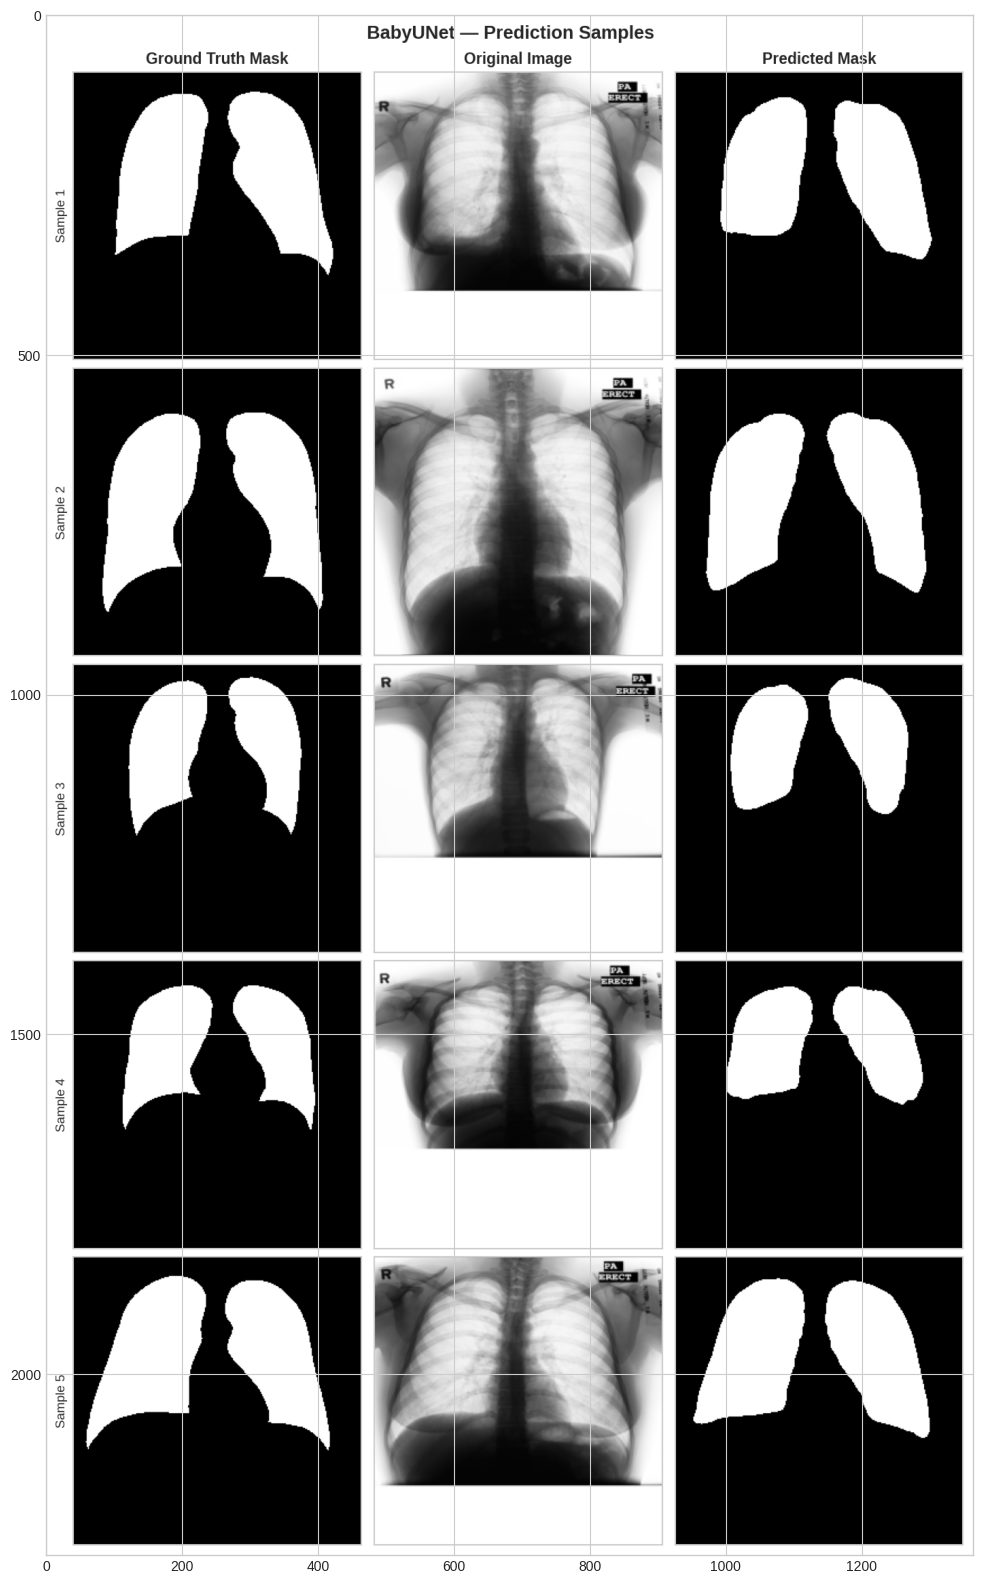

In [21]:
predictions_img_path = "/content/predictions.png"
plot_saved_img(predictions_img_path)